频谱：像素变化剧烈的区域对应高频信息；像素变化不大的区域对应低频信息

滤波：过滤某些频率的信息

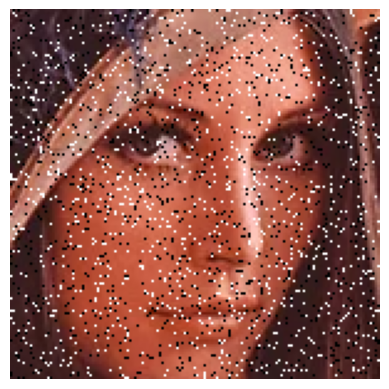

In [2]:
from utils import *

# 添加椒盐噪声
def add_Salt(img, pro):
    # img为输入图像
    # pro为椒盐噪声的比例
    
    # 添加黑色像素点
    noise = np.random.uniform(0, 255, img[:, :, 0].shape)
    # mask为添加噪声的掩模
    mask = noise < pro * 255
    # 扩展mask的维度
    mask = np.expand_dims(mask, axis=2)
    mask = np.repeat(mask, 3, axis=2)    
    img = img * (1 - mask)
     
    # 添加白色像素点
    mask = noise > 255 - pro * 255    
    mask = np.expand_dims(mask, axis=2)
    mask = np.repeat(mask, 3, axis=2)
    noise_img = 255 * mask + img * (1 - mask)
    
    return noise_img


img = cv2.imread('lenaface.jpg')
# 添加椒盐噪声的图像：
img_salt = add_Salt(img, 0.05)
plt.imshow(img_salt[:,:,::-1])
plt.axis('off')
plt.show()

高斯噪声：概率密度服从高斯分布的噪声

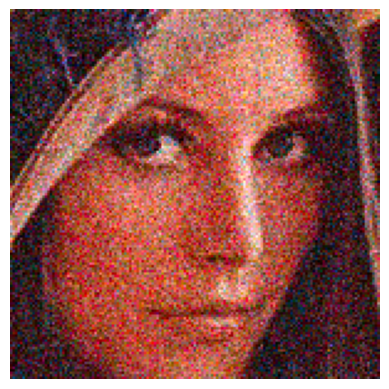

In [3]:
def add_Gaussian(img, sigma=20, mean=0):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
    lab = lab.astype(float)

    for i in range(0, 3):
        # 生成高斯噪声
        noise = np.random.normal(mean, sigma, lab[:, :, i].shape)
        # 添加高斯噪声
        lab[:, :, i] = lab[:, :, i] + noise
        lab[:, :, i] = np.clip(lab[:, :, i], 0, 255)

    lab = lab.astype(np.uint8)
    noise_img = cv2.cvtColor(lab, cv2.COLOR_Lab2BGR)
    
    return noise_img

# 添加高斯噪声的图像
img_gaussian = add_Gaussian(img)
plt.imshow(img_gaussian[:,:,::-1])
plt.axis('off')
plt.show()

**均值滤波器**

输出图像具有明显的“块状效应”

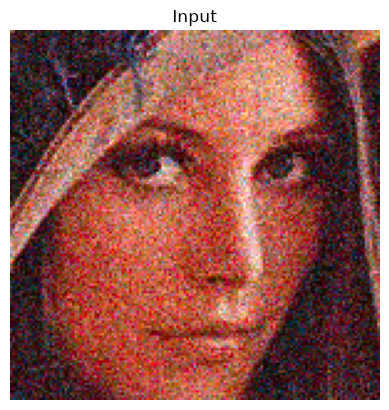

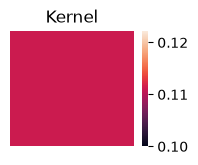

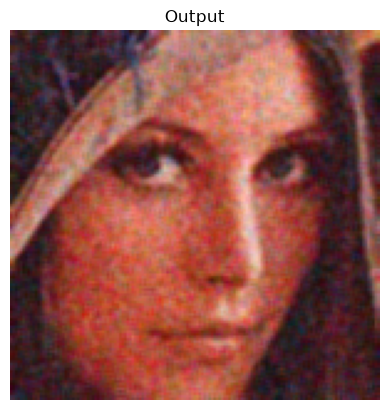

In [4]:
# 均值滤波器 size=3
size = 3
k3 = 1/size/size * np.ones((size, size))

# 展示输入图像与滤波核
conv_gaussian = conv_2d(img_gaussian, k3)
conv_gaussian.plot()

# 展示卷积结果
conv_gaussian.plot_conv()

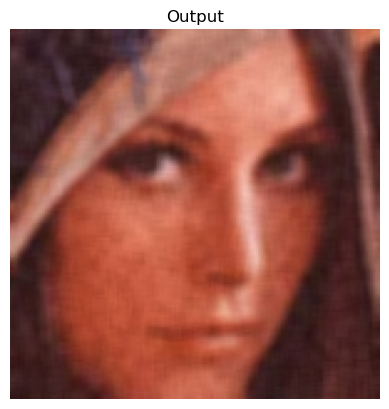

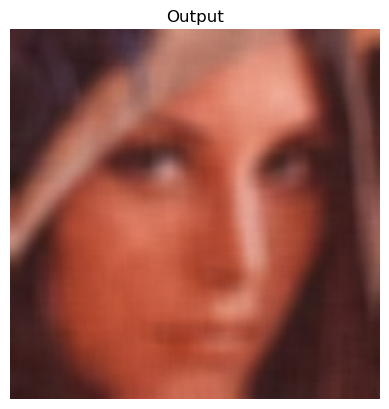

In [4]:
# 均值滤波器 size=5
size = 5
k5 = 1/size/size *np.ones((size,size))

conv = conv_2d(img_gaussian, k5)

# 展示卷积结果
conv.plot_conv()


# 均值滤波器 size=9
size = 9
k9 = 1/size/size * np.ones((size, size))

conv = conv_2d(img_gaussian, k9)
# 展示卷积结果
conv.plot_conv()

**高斯滤波器**

对邻域内每个像素进行加权平均，权重由高斯分布确定

相比于均值滤波，高斯滤波的输出图像更加平滑

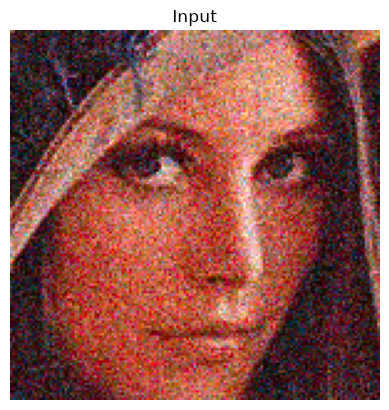

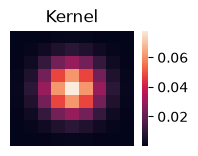

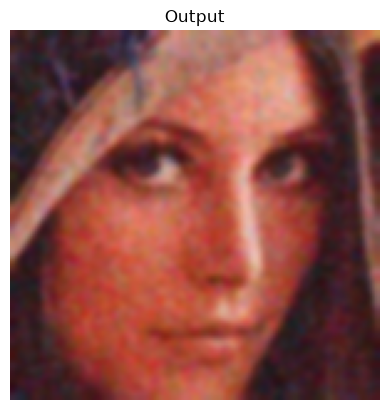

In [7]:
# 定义高斯核
def gauss(kernel_size, sigma):
    
    kernel = np.zeros((kernel_size, kernel_size))
    # 定义中心点坐标
    center = kernel_size // 2
    s = sigma ** 2
    sum_val =  0
    # 计算每个位置的高斯核权重
    for i in range(kernel_size):
        for j in range(kernel_size):
            x, y = i-center, j-center
            
            kernel[i, j] = np.exp(-(x**2 + y**2)/ 2 * s)
            sum_val += kernel[i, j]
    
    kernel = kernel/sum_val
    
    return kernel

k_gaussian = gauss(9, 0.7)
# 展示输入图像与滤波核
conv = conv_2d(img_gaussian, k_gaussian)
conv.plot()

# 展示卷积结果
conv.plot_conv()

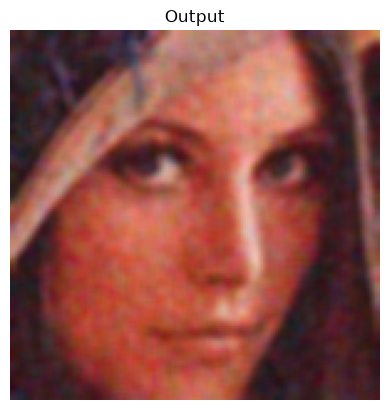

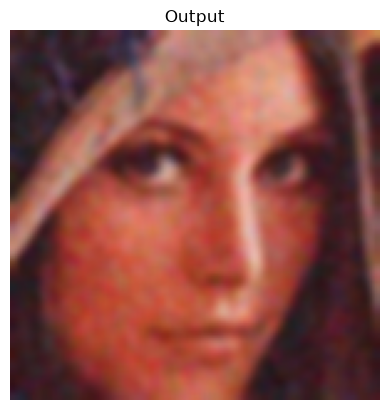

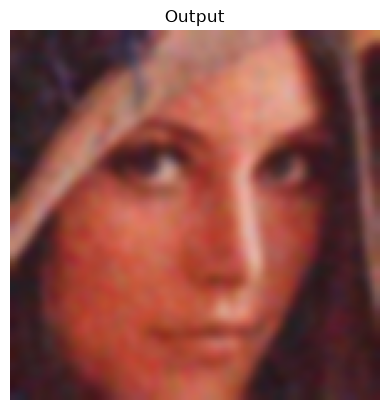

In [8]:
# 高斯核大小为5
conv1 = conv_2d(img_gaussian, gauss(5, 0.5))
conv1.plot_conv()

# 高斯核大小为7
conv2 = conv_2d(img_gaussian, gauss(7, 0.5))
conv2.plot_conv()

# 高斯核大小为11
conv3 = conv_2d(img_gaussian, gauss(11, 0.5))
conv3.plot_conv()

**双边滤波器**

邻域内像素值与中心像素值的差别越小，影响越大

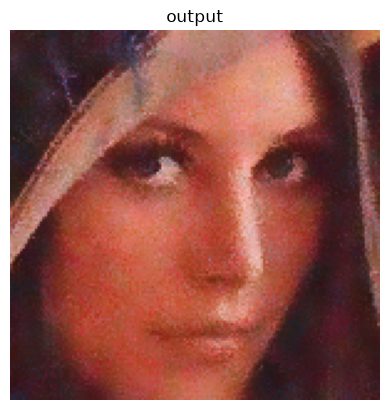

In [9]:
def plot_image(img, name, camp='gray'):
    plt.imshow(img, cmap=camp)
    plt.title(name)
    plt.axis('off')
    plt.show()

plot_image(cv2.bilateralFilter(np.uint8(img_gaussian),10,110,5)[:, :, ::-1], 'output')


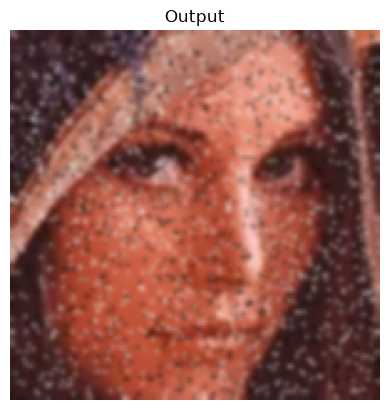

In [10]:
# 使用高斯滤波器过滤椒盐噪声
conv_salt = conv_2d(np.uint8(img_salt), gauss(5, 1))
conv_salt.plot_conv()

**中值滤波器**

图像像素等于周围像素排序后的中值\
由于正常像素的多数性，统计排序的中值通常是正常像素的像素值

常用于处理椒盐噪声

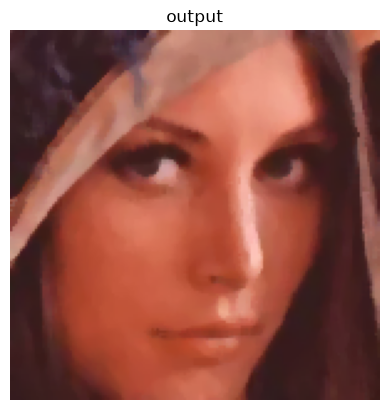

In [11]:
conv_salt = conv_2d(img_salt, k3)
plot_image(cv2.medianBlur(np.uint8(img_salt),5)[:, :, ::-1], 'output')

**图像锐化**

增强高频信息

将原图减去高斯滤波后的图像，得到图像的高频信息\
反复叠加在原图上，可以不断增强锐化的效果

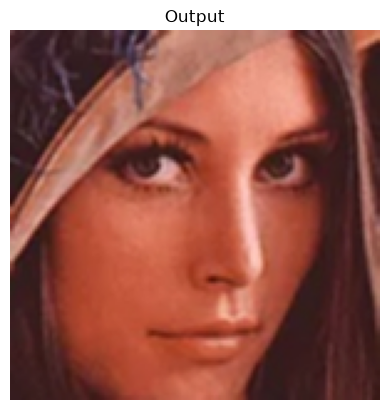

In [12]:
size = 3
k0 = np.zeros((size, size))
k0[int((size-1)/2)][int((size-1)/2)] = 1
kg = gauss(size, 1)

# 构建滤波核
k_shapen = k0 + 1 * (k0 - kg)
img_gau = cv2.GaussianBlur(img, (3,3), 1)
shapen = conv_2d(img_gau, k_shapen)
shapen.plot_conv()

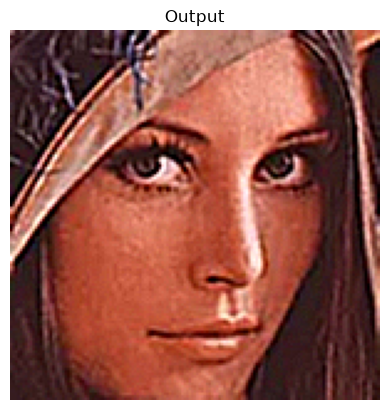

In [13]:
k_shapen = k0 + 10 * (k0 - kg)
img_gau = cv2.GaussianBlur(img, (3,3), 1)
shapen = conv_2d(img_gau, k_shapen)
shapen.plot_conv()